# Model 관리 실습

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
%%capture
!pip install gym[classic_control]

In [4]:
import tensorflow as tf
import keras
import tensorflow_probability as tfp
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import Adam

import numpy as np
import gym
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore")

## Environment : CartPole 생성

In [5]:
env = gym.make('CartPole-v1')
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.n

## Neural Network 만들기  

In [6]:
def NueralNetwork(state_size=4, action_size=2, hidden_size=24, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(hidden_size, input_dim=state_size,
                    activation='relu', kernel_initializer='glorot_uniform'))
    model.add(Dense(hidden_size, activation='relu', kernel_initializer='glorot_uniform'))
    model.add(Dense(action_size, activation='softmax', kernel_initializer='glorot_uniform'))
    return model

In [7]:
net = NueralNetwork(state_size=s_dim, action_size=a_dim)
net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 24)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

## REINFORCE Agent 만들기   
### Episode단위로 학습 하기


### Trajectory를 받아서 저장, done을 만나면 return값을 계산해서 보관  

In [8]:
class Trajectory:

    def __init__(self, gamma: float):
        self.gamma = gamma
        self.states = list()
        self.actions = list()
        self.rewards = list()
        self.next_states = list()
        self.dones = list()

        self.length = 0
        self.returns = None
        self._discounted = False

    def push(self, state, action, reward, next_state, done):
        if done and self._discounted:
            raise RuntimeError("done is given at least two times!")

        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.dones.append(done)
        self.length += 1

        if done and not self._discounted:
            # compute returns
            self.compute_return()

    def compute_return(self):
        rewards = self.rewards
        returns = list()

        g = 0
        # iterating returns in reverse order
        for r in rewards[::-1]:
            g = r + self.gamma * g
            returns.insert(0, g)
        self.returns = returns
        self._discounted = True

    def get_samples(self):
        states = np.array(self.states)    # na.array() <- list()
        actions = np.array(self.actions)  # (steps,)   <- [a,a,..]
        rewards = np.array(self.rewards)
        next_states = np.array(self.next_states)
        dones = np.array(self.dones)
        returns = np.array(self.returns)
        return states, actions,rewards,next_states, dones, returns


In [9]:
# queue : FIFO
# deque : 양쪽 방향에서 element 추가, 제거 가능
from collections import deque

class EpisodicMemory:

    def __init__(self, max_size: int, gamma: float):
        self.max_size = max_size  # maximum number of trajectories
        self.gamma = gamma
        self.trajectories = deque(maxlen=max_size) #trajectory들을 저장
        self._trajectory = Trajectory(gamma=gamma)

    def push(self, state, action, reward, next_state, done):
        self._trajectory.push(state, action, reward, next_state, done)
        if done: #episode가 끝나면 전체 trajectory 저장
            self.trajectories.append(self._trajectory)
            self._trajectory = Trajectory(gamma=self.gamma)

    def reset(self):
        self.trajectories.clear()
        self._trajectory = Trajectory(gamma=self.gamma)

    def get_samples(self):
        states,actions,rewards,next_states,dones,returns = [],[],[],[],[],[]
        while self.trajectories:           # trajecory들을 모두 꺼내어 분해, 조립
            traj = self.trajectories.pop() # 하나의 Traj. 가져오고
            s, a, r, ns, done, g = traj.get_samples()# trajectory 분해
            states.append(s)               #모든 traj.의 states 모음
            actions.append(a)
            rewards.append(r)
            next_states.append(ns)
            dones.append(done)
            returns.append(g)

        states = np.concatenate(states)    # (steps,s) <- [(s,),(s,),...]
        actions = np.concatenate(actions)  # (steps,)
        rewards = np.concatenate(rewards)  # (steps,)
        next_states = np.concatenate(next_states)
        dones = np.concatenate(dones)
        returns = np.concatenate(returns)

        return states, actions, rewards, next_states, dones, returns

### REINFORCE Agent 수정


In [10]:

class REINFORCE:
    def __init__(self, policy_model,
                 gamma = 1.0, lr = 0.001):
        super(REINFORCE, self).__init__()
        self.model = policy_model
        self.gamma = gamma
        self.optimizer = Adam(learning_rate=lr) # NN optimizer
        self._eps = 1e-25

    def get_action(self, state): # action <- sampling(model(state))
        prob_a = self.model.predict(state, batch_size=1,verbose=0).flatten()
        return np.random.choice(2, 1, p=prob_a)[0] #p(left, right)에서 sampling

    def _pre_process_inputs(self,episode):# epi. trejectory를 역순으로 재배치
        states, actions, rewards = episode
        states = np.flip(states,axis=0) #(steps,s)
        actions = np.flip(actions)      #(steps,)
        rewards = np.flip(rewards)      #(steps,)
        return states, actions, rewards

    def loss(self, prob_a, action, gt):
        dist = tfp.distributions.Categorical(probs=prob_a, dtype=tf.float32)
        log_prob = dist.log_prob(action) # = log(P(pi(prob_a<-model(s))|a))
        loss = -log_prob * gt            # = - log(pi(selected_a))*gt
        return loss

    # sample-by-sample update version of REINFORCE
    def update(self, episode):
        ## _pre_process_inputs: trajectory 순서 뒤집기,뒤부터 gamma적용하기 위해
        states, actions, rewards = self._pre_process_inputs(episode)
        g = tot_loss = cnt = 0
        for i,(s, a, r) in enumerate(zip(states, actions, rewards)): # step반복
            with tf.GradientTape() as tape:
                g = r + self.gamma * g                    # 현 setp에서 Gt 계산
                prob_a = self.model(s.reshape(1,4), training=True)#두action의 확률
                loss = self.loss(prob_a, a, g)            # -log(pi(selected_a))*Gt
            grads = tape.gradient(loss, self.model.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
            tot_loss += loss
            cnt = i+1
        return tot_loss/cnt

    ## episodes ## batch update version of REINFORCE
    def update_episodes(self, states, actions, returns, use_norm=True):
        if use_norm:  ## return값 Normalization
            returns = (returns - returns.mean())/(returns.std()+self._eps)
        with tf.GradientTape() as tape:
            prob_a = self.model(states.reshape(-1,4), training=True) #(steps,2)
            losses = self.loss(prob_a, actions, returns)             #(steps,)
            loss = tf.math.reduce_mean(losses)                       # sclar
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

# Model Management

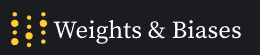

## Model의 수정내용, 결과를 자동화 통합 관리해 보자


모델 개발은 수많는 수정과정이 필요  
>각각의 수정사항(Hyper Parameter)과 결과를 통합 관리가 필요함  
>결과를 jupyter notebook에 포함하여 관리하는 것은 한계가 분명
>>여러가지 결과를 비교하지 힘들고  
>>수정사항이 명확하게 보이지 않음  
>>모델을 저장해도 저장된 모델의 hyper parameter는 별도로 관리해야 함

솔루션을 통해 관리점을 최소화 자동화 할 필요가 있음   
>간단한 솔루션  `wandb` (Weight AND Bias)를 사용해 보자  
>`Weight AND Bias` solution은 local에 설치도 가능함    

## wandb 설정하기


#### 1. wandb 계정 만들기 <br>
wandb https://wandb.ai/site 에 접속하여 계정을 생성  

#### 2. `wandb` pakage install하기



In [11]:
%%capture
!pip install wandb

#### 3. wandb login 하기
`'your-api-key'`는 https://app.wandb.ai/settings 페이지에서 `API keys`에서 가져옴  

```bash

```



In [12]:
#!wandb login '<YOUR_WANDB_API_KEY>'

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## wandb로 logging 하기

In [13]:
import wandb
import json
import os; os.environ['WANDB_NOTEBOOK_NAME'] = 'jyp' # jupyter notebook
from os.path import join

## Training

In [14]:
memory = EpisodicMemory(max_size=100, gamma=1.0)

### `wandb.config`로 모델의 Configuration 기록  


In [ ]:
update_every = 1 # Update episodes
epochs = 10
n_eps = 50

config = dict()
config['update_every'] = update_every
config['epochs'] = epochs
config['n_eps'] = n_eps

n_project='rl-2211'
wandb.init(project=n_project, config=config)

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find jyp.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: gshong (rl-2211). Use `wandb login --relogin` to force relogin


### `wandb.log()`로 logging할 값들 저장  

In [ ]:
%%time
net = NueralNetwork(state_size=s_dim, action_size=a_dim)
agent = REINFORCE(net)
memory.reset()

scores = [0]
mean_r = 0
tot_loss = 0

for ep in range(n_eps): # episode 반복
    s = env.reset()     # evn. 초기화
    cum_r = 0           # epi.내에서 reward sum
    states = []
    actions = []
    rewards = []
    while True:         # 하나의 episode 시행
        s = np.reshape(s, (1, 4))       # (bs,s)
        a = agent.get_action(s)         # plocy net. 출력에서 sampling한 action
        ns, r, done, info = env.step(a) # env. feedback
        memory.push(s,a,r,ns,done)
        s = ns                          # state update
        cum_r += r                      # epi. 길이 (epi.score)
        if done: break                  # Termination
    scores.append(cum_r)
    if ep % update_every == 0:
        s,a, _, _, done, g = memory.get_samples()
        for i in range(epochs):
            loss = agent.update_episodes(s, a, g) # use_norm=True
            tot_loss += loss
            mean_score = np.mean(scores[-min(10,len(scores)):])
        tot_loss = tot_loss / epochs
        print(f"Epi./Iter. {ep}/{epochs*ep//update_every} || mean_score: {mean_score:03f} ||  Tot_Loss: {tot_loss:06f} ")
    if mean_score > 300 : break

    log_dict = dict()
    log_dict['cum_return'] = cum_r
    log_dict['mean_score'] = mean_score
    wandb.log(log_dict)

# Save model and experiment configuration
json_val = json.dumps(config)                            # json format을 준비
with open(join(wandb.run.dir, 'config.json'), 'w') as f: # server의 기본 path을 받아서
    json.dump(json_val, f)                               # 'config.jon'파일명으로 저장
keras.models.save_model(net, join(wandb.run.dir, 'REINFORCE_Norm.h5'))
# close wandb session
wandb.join()

Epi./Iter. 0/0 || mean_score: 8.500000 ||  Tot_Loss: -0.021564 
Epi./Iter. 1/10 || mean_score: 12.000000 ||  Tot_Loss: 0.022272 
Epi./Iter. 2/20 || mean_score: 24.500000 ||  Tot_Loss: 0.000826 
Epi./Iter. 3/30 || mean_score: 29.600000 ||  Tot_Loss: 0.002211 
Epi./Iter. 4/40 || mean_score: 28.000000 ||  Tot_Loss: -0.012806 
Epi./Iter. 5/50 || mean_score: 31.714286 ||  Tot_Loss: -0.008168 
Epi./Iter. 6/60 || mean_score: 33.625000 ||  Tot_Loss: -0.008788 
Epi./Iter. 7/70 || mean_score: 33.777778 ||  Tot_Loss: 0.000855 
Epi./Iter. 8/80 || mean_score: 32.000000 ||  Tot_Loss: -0.120939 
Epi./Iter. 9/90 || mean_score: 37.200000 ||  Tot_Loss: -0.015579 
Epi./Iter. 10/100 || mean_score: 40.200000 ||  Tot_Loss: -0.007852 
Epi./Iter. 11/110 || mean_score: 44.500000 ||  Tot_Loss: 0.018678 
Epi./Iter. 12/120 || mean_score: 42.600000 ||  Tot_Loss: 0.055781 
Epi./Iter. 13/130 || mean_score: 45.800000 ||  Tot_Loss: -0.001336 
Epi./Iter. 14/140 || mean_score: 46.300000 ||  Tot_Loss: 0.000343 
Epi./Iter

Epi./Iter. 49/490 || mean_score: 102.400000 ||  Tot_Loss: 0.003255 


cum_return,▁▁▃▁▃▂▁▃▂▃▄▁▁▂▂▄▅▂▁▁▃▂▂▄▅▃▃▁▄▂▅▃▄▄▃▄▄█▅▄
mean_score,▁▁▂▃▃▃▃▃▃▄▄▄▄▄▃▄▄▄▄▃▄▄▄▄▄▅▅▅▅▅▅▆▆▅▅▆▆▆▇█
cum_return,91
mean_score,102.4


CPU times: user 3min 14s, sys: 2.96 s, total: 3min 17s
Wall time: 3min 25s


## 저장된 파일 불러오기

`wandb`저장된 모델의 파라미터 확인 및 불러오기

* config.jon 파일의 내용을 확인  

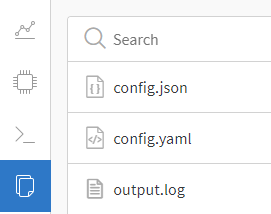

* 저장된 file path 거져오기

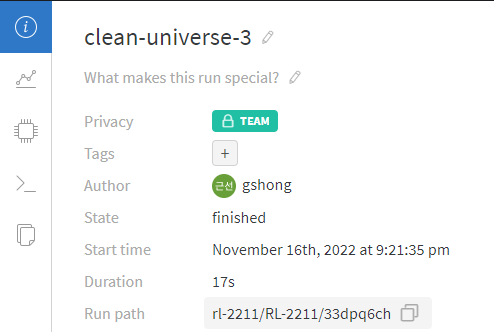

`Run path`를 복사해서 아래에 붙여 넣자  

In [ ]:
wandb_run_path = 'rl-2211/RL-2211/w0pnb6qh' ### 수정!!
model_config_path = wandb.restore('config.json', wandb_run_path, replace=True)

In [ ]:
with open(model_config_path.name, "r") as f:
    config_str = json.load(f)
    config_loaded = json.loads(config_str)

In [ ]:
print("Config")
print(config)

print("loaded config")
print(config_loaded)

Config
{'update_every': 1, 'epochs': 10, 'n_eps': 50}
loaded config
{'update_every': 1, 'epochs': 10, 'n_eps': 50}


In [ ]:
model_path = wandb.restore('REINFORCE_Norm.h5', wandb_run_path, replace=True)
net2 = keras.models.load_model(model_path.name)
net2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 24)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

## Evaluation

In [ ]:
%%time
%%capture
!pip install gym pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="REINFORCE_Norm_r")

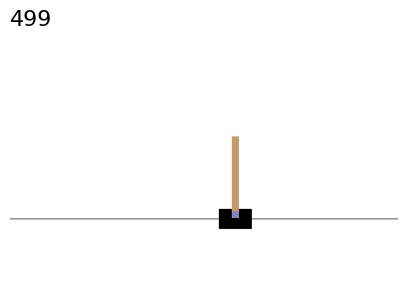

In [ ]:
state = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = net2.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='REINFORCE_Norm_r')

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE_Norm_r-episode-0.mp4
